# Módulo de Regressão

Desejamos boas-vindas ao módulo de Regressão!

Aqui será explorada a tarefa de prever valores numéricos com base em dados, outro pilar fundamental do Machine Learning.

Antes de começar os experimentos, será feita uma breve revisão dos conceitos básicos que explicam o que é Regressão, como ela funciona e quando é usada.

📌 Créditos pelo notebook:
Yago Primerano, Felipe Antonio [?]

## Revisão

### O que é Regressão?
A Regressão também é uma tarefa do Machine Learning supervisionado, assim como a Classificação. Mas aqui, ao invés de prever uma classe — gato vs cachorro, possuir problema cardíaco vs não possuir —, o modelo tenta prever um número contínuo — preço, temperatura, distância.

Imagine que você quer prever o preço de uma garrafa de vinho com base em informações como o país de origem, a pontuação dada por um especialista, e a variedade da uva. Esse é um problema de regressão, pois a resposta esperada (o preço) é um número — não uma categoria.

### Exemplos do mundo real:
- Prever o preço de uma casa com base em seu tamanho e localização.
- Estimar a temperatura de amanhã com base em dados meteorológicos.
- Calcular o lucro esperado de uma empresa no próximo mês.
- Prever a nota de um vinho com base em suas características.

### Como funciona?
O modelo de regressão tenta encontrar uma relação matemática — uma função — entre as variáveis de entrada (as features) e o valor numérico que deve ser previsto.

Por exemplo: Se temos um conjunto de dados com:

- country: país de origem
- variety: tipo da uva
- price: preço do vinho

Podemos treinar um modelo para prever a pontuação (points) que o vinho vai receber. Como points é uma variável numérica, este é um problema de regressão.

### O que o modelo aprende?
O modelo de regressão tenta ajustar uma função que melhor representa os dados. A função pode ser simples, como uma linha reta (regressão linear), ou mais complexa, dependendo do tipo de relação entre os dados. Segue um exemplo de representação de regressão:

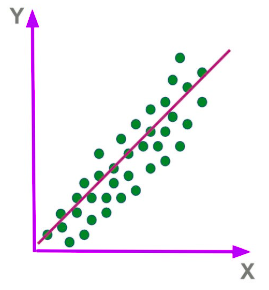

Nesse caso acima, queremos prever o valor de $Y$ em função da feature $X$, e cada ponto representa uma instância dos nossos dados. Caso estivéssemos trabalhando como um dataframe, cada instância (ponto) seria representado por uma linha do dataframe. Além disso, a linha reta roxa entre os pontos representam a função que melhor representa a tendência dos dados.

Voltando para nosso exemplo anterior, a ideia é que, dada uma nova instância (um novo vinho, por exemplo), o modelo consiga estimar um valor para a variável que queremos prever (como a nota ou o preço).

Afim de exemplificar os conceitos ao longo da aula, seguimos com o seguinte exemplo prático de uma base de dados contendo componentes de cimento e a sua respectiva resistência:

In [ ]:
import pandas as pd

# Suponha que você tenha o DataFrame 'data'
data = pd.read_csv('https://cocl.us/concrete_data')

# Dicionário de tradução das colunas
colunas_traduzidas = {
    'Cement': 'Cimento',
    'Blast Furnace Slag': 'Escória de Alto Forno',
    'Fly Ash': 'Cinzas Volantes',
    'Water': 'Água',
    'Superplasticizer': 'Superplastificante',
    'Coarse Aggregate': 'Agregado Grosso',
    'Fine Aggregate': 'Agregado Fino',
    'Age': 'Idade',
    'Strength': 'Resistência'
}

# Renomeando as colunas do DataFrame
data.rename(columns=colunas_traduzidas, inplace=True)

# Exibindo as primeiras linhas do DataFrame com as colunas renomeadas
print(data.head())

   Cimento  Escória de Alto Forno  Cinzas Volantes   Água  Superplastificante  \
0    540.0                    0.0              0.0  162.0                 2.5   
1    540.0                    0.0              0.0  162.0                 2.5   
2    332.5                  142.5              0.0  228.0                 0.0   
3    332.5                  142.5              0.0  228.0                 0.0   
4    198.6                  132.4              0.0  192.0                 0.0   

   Agregado Grosso  Agregado Fino  Idade  Resistência  
0           1040.0          676.0     28        79.99  
1           1055.0          676.0     28        61.89  
2            932.0          594.0    270        40.27  
3            932.0          594.0    365        41.05  
4            978.4          825.5    360        44.30  


### Cement → Cimento
    Quantidade de cimento (em kg) usada para fabricar o concreto. O cimento é um dos principais ingredientes, responsável pela durabilidade e resistência do concreto.
### Blast Furnace Slag → Escória de Alto Forno
    Quantidade de escória de alto forno (em kg), um subproduto da produção de ferro e aço. A escória é adicionada ao concreto para melhorar suas propriedades, como resistência à compressão e durabilidade.
### Fly Ash → Cinzas Volantes
    Quantidade de cinzas volantes (em kg), um subproduto da queima de carvão em usinas de energia. As cinzas volantes também são usadas como substituto do cimento em alguns casos, ajudando a melhorar a trabalhabilidade e a durabilidade do concreto.
### Water → Água
    Quantidade de água (em kg) adicionada à mistura de concreto. A proporção de água é crucial para controlar a relação água-cimento, que afeta a resistência e durabilidade do concreto.
### Superplasticizer → Superplastificante
    Quantidade de superplastificante (em kg), que é um aditivo químico utilizado para aumentar a fluidez do concreto, permitindo que menos água seja usada na mistura, sem comprometer a trabalhabilidade.
### Coarse Aggregate → Agregado Grosso
    Quantidade de agregado grosso (em kg), como pedras ou cascalho, usado na mistura de concreto. O agregado grosso fornece a estrutura e a resistência ao concreto.
### Fine Aggregate → Agregado Fino
    Quantidade de agregado fino (em kg), geralmente composto de areia, usado na mistura de concreto. O agregado fino preenche os espaços vazios entre as partículas do agregado grosso e ajuda a melhorar a trabalhabilidade.
### Age → Idade
    Idade do concreto (em dias), ou seja, o tempo que o concreto foi curado ou curado após a mistura. A resistência do concreto aumenta com o tempo à medida que ele cura.
### Strength → Resistência
    A resistência à compressão do concreto (em MPa), que é a capacidade do concreto de suportar forças de compressão. Essa é a variável alvo que queremos prever.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


# Separar variáveis preditoras e alvo
X = data.drop('Resistência', axis=1)
y = data['Resistência']

# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def imprimir_metricas(modelo, X_teste, y_teste, y_pred):
    """
    Função para calcular e imprimir as métricas de desempenho (MSE e R²) de um modelo.

    Parâmetros:
    modelo (object): O modelo treinado.
    X_teste (DataFrame ou array): Dados de entrada para teste.
    y_teste (array): Valores reais do alvo para o conjunto de teste.
    y_pred (array): Valores preditos pelo modelo.
    """
    # Erro quadrático médio (MSE)
    mse = mean_squared_error(y_teste, y_pred)

    # Coeficiente de determinação (R²)
    r2 = r2_score(y_teste, y_pred)

    # Exibindo as métricas
    print(f"Desempenho do modelo ({modelo.__class__.__name__}):")
    print(f"Erro Quadrático Médio (MSE): {mse:.3f}")
    print(f"Coeficiente de Determinação (R²): {r2:.3f}")
    print("-" * 50)

# 1) Da equação da reta e do plano à Regressão Linear

Toda pessoa que concluiu o ensino médio já se deparou com a famosa equação da reta, geralmente escrita como

$$
y = a\,x + b
$$

onde $a$ é o **coeficiente angular**, responsável por indicar quão inclinada a reta fica, e $b$ é o **coeficiente linear** (ou **intercepto**), que determina o ponto onde a reta cruza o eixo vertical $y$, que ocorre quando $x=0$. Graficamente, sempre que escolhemos um valor de $x$, a reta nos dá o valor correspondente de $y$.

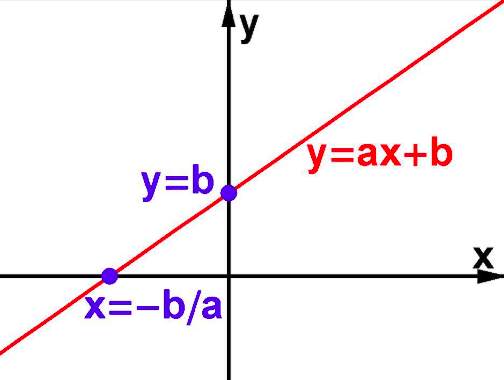

Menos comum do que a equação da reta, mas também aprendemos na escola sobre planos, e no espaço tridimensional podemos ter a equação de um plano:

$$
z = a\,x + b\,y + c
$$

Neste caso, $a$ e $b$ controlam a inclinação do plano ao longo de duas direções (o eixo $x$ e o eixo $y$) e $c$ é o valor de $z$ quando $x$ e $y$ são ambos zero. Imagine uma folha de papel inclinada dentro do espaço: sua “altura” em cada ponto depende dos coeficientes $a$ e $b$, e seu ponto de apoio no eixo vertical é $c$.

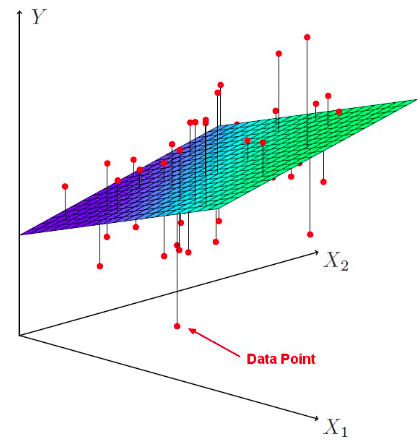

Em regressão linear, fazemos exatamente o mesmo tipo de reta ou de plano, porém **não escolhemos** esses coeficientes (os coeficientes $a$, $b$, $c$) arbitrariamente — **ajustamos** a reta ou o plano para que eles fiquem o mais próximo possível de uma nuvem de pontos que representam nossos dados observados.

Por exemplo, se você medir a idade de vários carros ($X$) e os preços pelos quais foram vendidos ($Y$), terá uma nuvem de pontos $(x_j, y_j)$ num gráfico.


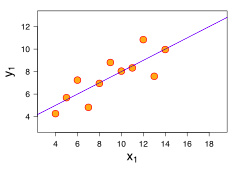

Para mais informações sobre dimensões espaciais, verifique o **apêndice A**.

 Queremos encontrar uma reta azul do formato:

$$
\hat y = b_{0} + b_{1}\,x
$$

Chamamos de $\hat y$ o preço previsto para nosso carro a partir da idade $x$ (nossa única feature). Perceba que essa fórmula é análoga à equação da reta que estudamos no ensino médio:


$$
y = b + a\,x
$$

A única diferença é que, nos estudos de regressão linear, convencionou-se de chamar os coeficientes de $b_{0}, b_{1}, ..., b_{n}$, ao invés de $a, b, c, ..., z$. Na equação da reta que estudamos no ensino médio, caso já tenhamos os valores dos coeficientes $a$ e $b$, e tenhamos um valor para $x$, conseguimos encontrar $y$. Por exemplo, suponha a equação da reta $y=3+7x$. Caso queiramos encontrar o valor de $y$ quando $x=5$, temos:

$ y=3+7x \Rightarrow y=3+7 \cdot 5 \Rightarrow  y = 3 + 35 \Rightarrow y = 38 $

Vejamos como é calculado está reta no nosso exemplo do concreto:

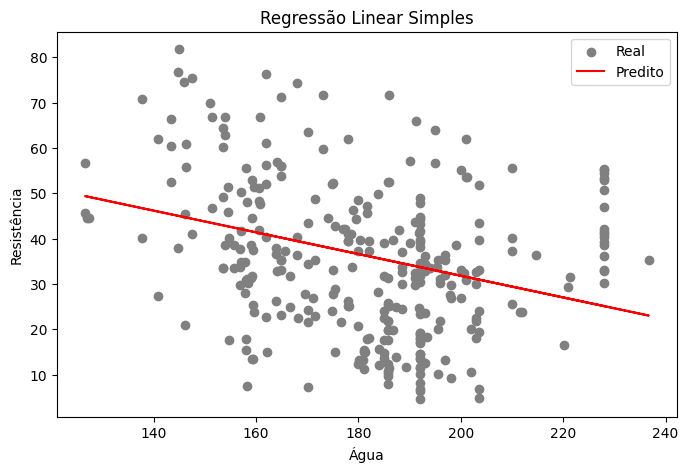

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 253.978
Coeficiente de Determinação (R²): 0.061
--------------------------------------------------
Coeficientes da reta: intercecpto -> 79.65983198280243; coeficientes -> [-0.23930458]


In [ ]:
# 1. Regressão Linear Simples (1 variável)
feature = 'Água'
X_train_simple = X_train[[feature]]
X_test_simple = X_test[[feature]]

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)
y_pred_simple = lr_simple.predict(X_test_simple)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, color='gray', label='Real')
plt.plot(X_test_simple, y_pred_simple, color='red', label='Predito')
plt.xlabel(feature)
plt.ylabel('Resistência')
plt.title('Regressão Linear Simples')
plt.legend()
plt.show()

# Chamando a função para imprimir as métricas
imprimir_metricas(lr_simple, X_test, y_test, y_pred_simple)
print(f"Coeficientes da reta: intercecpto -> {lr_simple.intercept_}; coeficientes -> {lr_simple.coef_}")

# 2) Por que essa Regressão é **Linear**?

O nome “linear” em regressão linear vem de como **os coeficientes** do modelo entram **de forma linear** na equação, e não do formato dos dados. Nosso modelo de regressão sempre assume a forma

$$
\hat Y = b_{0} + b_{1}\,X_{1} + b_{2}\,X_{2} + \dots + b_{p}\,X_{p},
$$

onde cada \($b_i$\) (também chamado de **coeficiente**) multiplica exatamente uma única **feature** \($X_i$\), e todos esses termos são **somados**. Essa soma ponderada de coeficientes e variáveis caracteriza uma **combinação linear** nos parâmetros \($b_i$\), o que garante várias vantagens práticas.

### Linearidade nos parâmetros

Quando falamos em “linear”, queremos dizer:

- **Linear em \($b_i$\)**: cada coeficiente aparece apenas multiplicando sua variável, nunca elevado ao quadrado ou em produto com outro coeficiente.  
- **Interpretação clara**: “Se aumentarmos \($X_i$\) em uma unidade, mantendo as outras constantes, esperamos que \($\hat Y$\) mude em \($b_i$\) unidades.”

Mesmo que queiramos capturar relações curvas ou interações, ainda podemos adicionar **novas variáveis** ao modelo — por exemplo, \($X^2$\), \($log(X)$\) ou \($X_1$ $\times\ X_2$\) — e continuar chamando o método de “regressão linear”, desde que a **previsão** mantenha-se uma soma de termos:

$$
\hat Y = b_{0} + b_{1}\,X + b_{2}\,(X^2) + b_{3}\,(X_1 \times X_2).
$$

Aqui, há efeitos quadráticos ou de interação nos dados, mas o modelo é **linear nos coeficientes** \($b_1$, $b_2$, $b_3$\).

### Exemplos do que **não** é regressão linear

1. **Modelo exponencial**:  
   $$\hat Y = b_0 \times e^{b_1 X}$$  
   Os coeficientes aqui aparecem dentro de uma função exponencial, não em soma simples, logo não é linear em \(b\).

2. **Rede neural simples**:  
   $$\hat Y = \sigma(b_0 + b_1 X)$$  
   Onde \($\sigma(\cdot)\$) é uma função sigmoide. A presença de \$(\sigma\$) impede a linearidade nos parâmetros.

3. **Interações não lineares entre coeficientes**:  
   $$\hat Y = b_0 + (b_1 \times b_2)\,X$$  
   O produto \($b_1$ $\times b_2$\) faz com que o modelo seja não linear em relação aos coeficientes.

### Visualizando em 2D, 3D e além

- **Em 2D** (uma única feature \($X$\)):  
  \($\hat y = b_{0} + b_{1}x\$) é a equação de uma reta.

- **Em 3D** (duas features \($X_1$, $X_2$\)):  
  \($\hat y = b_{0} + b_{1}x_1 + b_{2}x_2\$) define um plano.

- **Em espaços maiores** (mais de duas features):  
  falamos em **hiperplano**, mas o princípio — soma de contribuições lineares — é o mesmo.

### Vantagens da linearidade

1. **Solução única e eficiente**  
   A soma dos quadrados dos resíduos,
   $$
   S(b) = \sum_{j=1}^n \bigl(Y_j - \hat Y_j\bigr)^2,
   $$
   é uma função convexa em relação aos coeficientes, garantindo um **único mínimo global** obtido por álgebra ou métodos numéricos.

2. **Interpretação direta**  
   Cada \($b_i$\) indica “quanto muda \($\hat Y$\) se aumentarmos \($X_i$\) em uma unidade”, mantendo as demais variáveis fixas.

### Quando é preciso ir além

Se os dados exibem padrões curvos que uma reta ou plano não capturam, podemos:

- **Transformar features**: incluir \($X^2$\), \($\sqrt{X}$\) ou \($\log(X)$\), mantendo a linearidade nos coeficientes.  
- **Optar por modelos não lineares**: como árvores de decisão ou redes neurais, quando a estrutura linear não for suficiente.




# 3) Problema de regressão matematicamente

Quando nos deparamos com situações em que o objetivo é prever um valor numérico contínuo — por exemplo, estimar o preço de um imóvel, por  inar o peso de uma pessoa a partir de suas características ou predizer a altura de uma planta— estamos lidando com um problema de regressão. Nesses cenários, a variável resposta, representada por $Y$, é um valor real, e as features que usamos como base para essa predição são as variáveis explicativas ou features, denotadas por $\mathbf{X} = [X_{1},X_{2},\dots,X_{p}]$. Formalmente, supomos que exista uma função desconhecida $f$ capaz de relacionar as features ao target, de modo que

$$
Y = f(\mathbf{X}) + \varepsilon,
$$

onde $\varepsilon$ representa o termo de erro ou ruído, incorporando todas as variações não explicadas por $f$. Por exemplo, se quisermos inferir o preço de um carro a partir de sua idade e quilometragem, nosso objetivo é estimar essa relação contínua, em vez de classificar o veículo como “barato” ou “caro”.

### a. Regressão Linear: intuição e matemática detalhada

A regressão linear consiste em aproximar a função $f$ por um modelo de forma afim, que no caso univariado equivale a uma reta e, quando há múltiplas variáveis, a um hiperplano. Nesse modelo, a predição do valor $Y$ para a amostra $j$ é dada por

$$
\hat y_{j} = \beta_{0} + \beta_{1}x_{j1} + \beta_{2}x_{j2} + \cdots + \beta_{p}x_{jp},
$$

essa expressão implica que $\beta_{0}$ é o intercepto (o valor previsto quando todas as features são zero) e cada $\beta_{i}$ é o coeficiente que quantifica a influência da variável $X_{i}$ em $Y$. Para escolher os valores de $\beta_{0},\beta_{1},\dots,\beta_{p}$, utilizamos o critério dos mínimos quadrados, no qual minimizamos a soma dos quadrados dos resíduos: para cada observação $(x_{j1},\dots,x_{jp},y_{j})$, calculamos o resíduo

$$
e_{j} = y_{j} - \hat y_{j},
$$

e buscamos minimizar a função objetivo

$$
S(\boldsymbol{\beta}) = \sum_{j=1}^{n}e_{j}^{2} = \sum_{j=1}^{n}\bigl(y_{j} - \hat y_{j}\bigr)^{2}.
$$

Em termos matriciais, definimos a matriz $\mathbf{X}$ de dimensão $n\times(p+1)$ cuja primeira coluna é composta de uns (para capturar o intercepto) e as demais colunas contêm os valores das features, e o vetor $\mathbf{y}$ de dimensão $n\times1$. A solução fechada para os coeficientes é

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y},
$$

onde $\mathbf{X}^{\top}$ é a matriz transposta de $\mathbf{X}$ e $(\mathbf{X}^{\top}\mathbf{X})^{-1}$ é sua inversa, desde que as features não sejam perfeitamente colineares. O produto matricial resultante é um vetor de dimensão $(p+1)\times1$, cujas entradas são as estimativas $\hat{\beta}_{0},\hat{\beta}_{1},\dots,\hat{\beta}_{p}$.


### b. Avaliando a qualidade do ajuste: somatórios de quadrados, variância e $R^{2}$

Para entender o quanto nosso modelo aproxima-se bem dos dados, comparamos a variabilidade total de $Y$ com a variabilidade residual, isto é, os desvios entre valores observados e valores previstos. Primeiramente, calculamos a média dos alvos:

$$
\bar y = \frac{1}{n} \sum_{j=1}^{n}y_{j},
$$

e definimos o somatório de quadrados em torno da média ($SS_{\mathrm{mean}}$) como

$$
SS_{\mathrm{mean}} = \sum_{j=1}^{n}(y_{j} - \bar y)^{2}.
$$

Em seguida, a soma de quadrados do ajuste ($SS_{\mathrm{fit}}$) corresponde ao somatório dos quadrados dos resíduos

$$
SS_{\mathrm{fit}} = \sum_{j=1}^{n}(y_{j} - \hat y_{j})^{2} = \sum_{j=1}^{n}e_{j}^{2}.
$$

O coeficiente de determinação $R^{2}$ é então definido por

$$
R^{2} = 1 - \frac{SS_{\mathrm{fit}}}{SS_{\mathrm{mean}}} = \frac{SS_{\mathrm{mean}} - SS_{\mathrm{fit}}}{SS_{\mathrm{mean}}},
$$

sendo que $R^{2}$ varia de 0 a 1 e representa a fração da variância total de $Y$ explicada pelo modelo. Por exemplo, se ao calcularmos $SS_{\mathrm{mean}}$ obtivermos 32 e $SS_{\mathrm{fit}}$ for igual a 6, temos

$$
R^{2} = \frac{32 - 6}{32} = 0{,}81,
$$

indicando que 81% da variabilidade de $Y$ é capturada pelo ajuste.


### c. Relação entre correlação e $R^{2}$

Quando lidamos com apenas duas variáveis, a correlação linear $r$ mede a força e a direção da associação entre elas. Nesse caso particular, vale a relação simples

$$
R^{2} = r^{2}.
$$

Assim, se a correlação for $r = 0{,}9$, então $R^{2} = 0{,}81$, o que corresponde a 81% da variação explicada. Contudo, enquanto $r$ nos dá uma medida de associação, $R^{2}$ quantifica a porção de variância explicada, o que se torna especialmente útil ao lidar com múltiplas features.


### d. Testes estatísticos: estatística $F$ e $p$-valor

Para verificar se o ajuste observado pode ser atribuído ao acaso, utilizamos a estatística $F$, que compara a variância explicada pelo modelo à variância residual ajustada pelos graus de liberdade. Definimos

$$
F = \frac{(SS_{\mathrm{mean}} - SS_{\mathrm{fit}})/(p_{\mathrm{fit}} - p_{\mathrm{mean}})}{SS_{\mathrm{fit}}/(n - p_{\mathrm{fit}})},
$$

onde $p_{\mathrm{fit}}$ é o número total de parâmetros ajustados (incluindo intercepto), $p_{\mathrm{mean}}=1$ no modelo da média, e $n$ é o número de observações. O numerador representa a variância explicada por features por grau de liberdade do ajuste, e o denominador, a variância residual por grau de liberdade residual.

Sob a hipótese nula de ausência de relação real, $F$ segue uma distribuição $F$ com $(p_{\mathrm{fit}}-p_{\mathrm{mean}},\,n-p_{\mathrm{fit}})$ graus de liberdade. O $p$-valor associado é a probabilidade de observarmos um $F$ igual ou mais extremo do que o calculado, caso a hipótese nula seja verdadeira. Alternativamente, podemos estimar esse $p$-valor por simulação, gerando muitos conjuntos de dados aleatórios e avaliando a fração cujo $F$ excede nosso $F$ observado.


### e. Exercícios práticos e analogias

Para consolidar os conceitos, proponha-se a descrever em texto corrido o significado de cada resíduo $e_{j} = y_{j} - \hat y_{j}$, calcular manualmente coeficientes, somatórios de quadrados e $R^{2}$ para um pequeno conjunto de pontos, simular o cálculo de $F$ por meio de dados aleatórios a fim de estimar um $p$-valor aproximado e investigar o comportamento de $R^{2}$ e $R^{2}_{\mathrm{adj}}$ quando incluímos variáveis irrelevantes, refletindo sobre situações de overfitting.

Este texto corrido, rico em detalhamento e exemplos, foi elaborado para garantir fluidez no raciocínio e atender aos diferentes níveis de formação matemática dos alunos, oferecendo tanto intuições acessíveis quanto explicações técnicas precisas.

# 4) Além da simples Regressão Linear

A regressão linear corresponde a um dos métodos mais efetivos de aprendizagem de máquina, no que tange tanto à interpretabilidade do modelo quanto à acurácia de predição. Entretanto, tudo que é bom pode melhorar, e a seguir vejamos modelos que são extensões da Regressão Linear.

### a. Regressão Múltipla e $R^{2}$ ajustado

Quando adicionamos múltiplas variáveis explicativas, o modelo linear permanece afim em cada feature, formando um hiperplano em dimensão superior. Se introduzirmos, por exemplo, peso e comprimento de cauda para predizer o comprimento do corpo de um animal, nossa equação será

$$
\hat y_{j} = \beta_{0} + \beta_{1}x_{j1} + \beta_{2}x_{j2}.
$$

É importante notar que incluir novas variáveis reduz $SS_{\mathrm{fit}}$ mesmo que elas não tenham relação real com o target, o que pode levar ao overfitting. Para penalizar a introdução de parâmetros que não melhoram adequadamente o ajuste, define-se o $R^{2}$ ajustado:

$$
R^{2}_{\mathrm{adj}} = 1 - \frac{SS_{\mathrm{fit}}/(n - p_{\mathrm{fit}})}{SS_{\mathrm{mean}}/(n - p_{\mathrm{mean}})},
$$

onde os termos no denominador consideram os graus de liberdade correspondentes ao modelo ajustado e ao modelo da média. Dessa forma, se uma feature extra não reduzir proporcionalmente $SS_{\mathrm{fit}}$, o valor de $R^{2}_{\mathrm{adj}}$ diminuirá, sinalizando que a complexidade adicional não foi compensada por ganho de explicação.

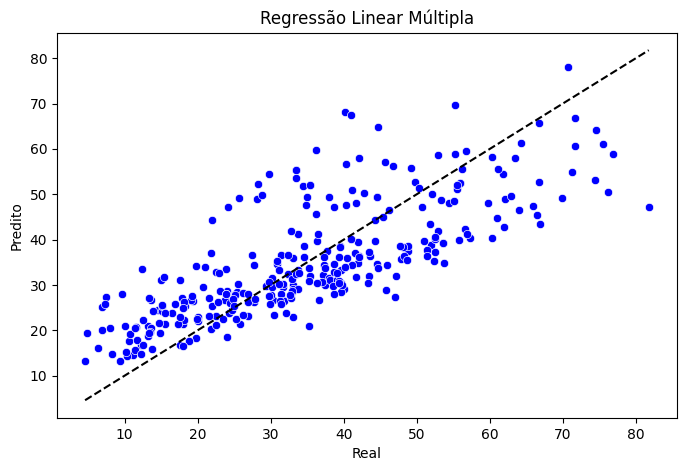

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 109.751
Coeficiente de Determinação (R²): 0.594
--------------------------------------------------
Coeficientes da reta: intercecpto -> -59.61868838556; coeficientes -> [ 0.12546445  0.11679076  0.09001377 -0.09057971  0.39649115  0.02810985
  0.03637553  0.1139419 ]


In [ ]:
# 2. Regressão Linear Múltipla
lr_multiple = LinearRegression()
lr_multiple.fit(X_train, y_train)
y_pred_multiple = lr_multiple.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_multiple, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear Múltipla')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_multiple, X_test, y_test, y_pred_multiple)
print(f"Coeficientes da reta: intercecpto -> {lr_multiple.intercept_}; coeficientes -> {lr_multiple.coef_}")

### b. Regressão Polinomial

Em certos casos, o modelo de regressão linear falha em explicar o problema. Assim, uma das possíveis soluções é a regressão polinomial, que consiste em um modelo quadrático da seguinte forma:

$$
\hat y_{j} = \beta_{0} + \beta_{1}x_{j1} + \beta_{2}x_{j2}^2.
$$

Ao contrário da regressão linear vista anteriormente, o modelo acima de grau $2$ representa uma curva em detrimento da reta que estávamos acostumados a observar. Podemos, ainda, expandir a regressão linear para $n$ graus do polinômio:

$$
\hat y_{j} = \beta_{0} + \beta_{1}x_{j1} + \beta_{2}x_{j2}^2 + \beta_{3}x_{j2}^3 + ... + \beta{n}x_{jn}^n.
$$

É interessante observar que, apesar de descrevermos as relações entre os dados de maneira polinomial, os coeficientes continuam a agir de maneira linear, valendo assim o mesmo processo de mínimos quadrados utilizado para calculá-los.

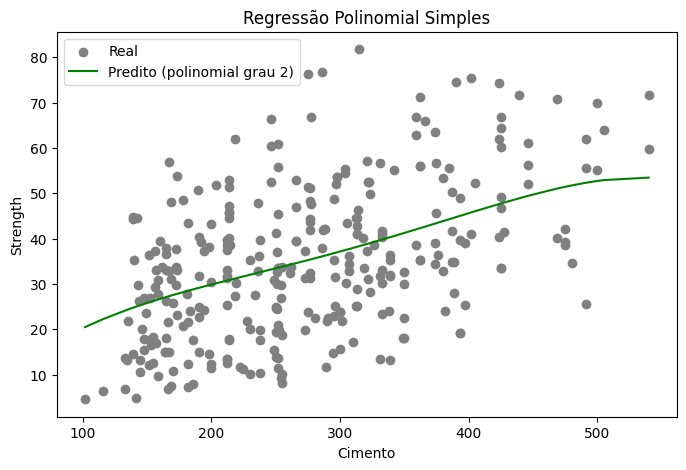

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 203.478
Coeficiente de Determinação (R²): 0.248
--------------------------------------------------


In [ ]:
# 3. Regressão Polinomial Simples (Cimento)
poly_simple = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly_simple.fit_transform(X_train_simple)
X_test_poly = poly_simple.transform(X_test_simple)

lr_poly_simple = LinearRegression()
lr_poly_simple.fit(X_train_poly, y_train)
y_pred_poly_simple = lr_poly_simple.predict(X_test_poly)

# Ordenar para plotagem suave
sort_idx = np.argsort(X_test_simple.values.ravel())
X_sorted = X_test_simple.values.ravel()[sort_idx]
y_sorted = y_pred_poly_simple[sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, color='gray', label='Real')
plt.plot(X_sorted, y_sorted, color='green', label='Predito (polinomial grau 2)')
plt.xlabel(feature)
plt.ylabel('Strength')
plt.title('Regressão Polinomial Simples')
plt.legend()
plt.show()
imprimir_metricas(lr_poly_simple, X_test, y_test, y_pred_poly_simple)

Melhor grau encontrado: 2


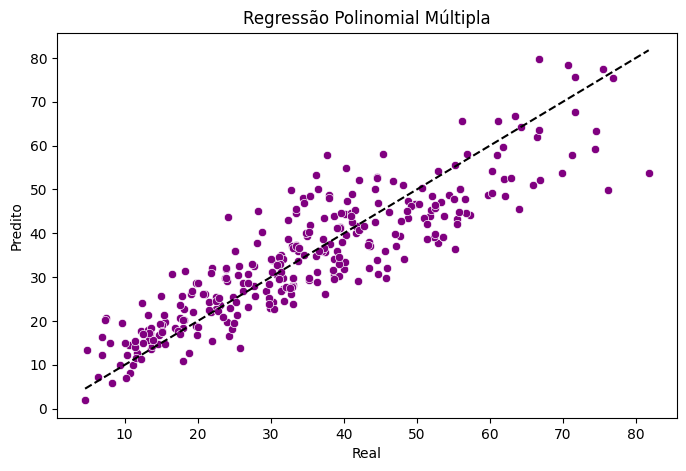

Desempenho do modelo (Pipeline):
Erro Quadrático Médio (MSE): 60.035
Coeficiente de Determinação (R²): 0.778
--------------------------------------------------


In [ ]:
# 4. Regressão Polinomial Múltipla com GridSearchCV
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('linear', LinearRegression())
])

param_grid = {
    'poly__degree': np.arange(1, 6)
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

melhor_modelo = grid_search.best_estimator_
melhor_grau = grid_search.best_params_['poly__degree']
print(f"Melhor grau encontrado: {melhor_grau}")

y_pred_poly_multi = melhor_modelo.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_poly_multi, color='purple')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title(f'Regressão Polinomial Múltipla')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()
imprimir_metricas(pipeline, X_test, y_test, y_pred_poly_multi)

In [ ]:
# Opcional: imprimir o polinômio encontrado
poly = melhor_modelo.named_steps['poly']
linear = melhor_modelo.named_steps['linear']
feature_names = poly.get_feature_names_out(X.columns)

print("\nPolinômio ajustado:")
print(f"y = {linear.intercept_:.3f} ", end="")
for coef, name in zip(linear.coef_, feature_names):
    print(f"{coef:+.3f}*{name} ", end="")
print()


Polinômio ajustado:
y = -5304.388 +2.715*Cimento +1.926*Escória de Alto Forno +1.931*Cinzas Volantes +15.675*Água +31.600*Superplastificante +3.259*Agregado Grosso +4.429*Agregado Fino +0.276*Idade -0.000*Cimento^2 -0.000*Cimento Escória de Alto Forno -0.000*Cimento Cinzas Volantes -0.005*Cimento Água -0.010*Cimento Superplastificante -0.001*Cimento Agregado Grosso -0.001*Cimento Agregado Fino +0.000*Cimento Idade -0.000*Escória de Alto Forno^2 +0.000*Escória de Alto Forno Cinzas Volantes -0.003*Escória de Alto Forno Água -0.010*Escória de Alto Forno Superplastificante -0.001*Escória de Alto Forno Agregado Grosso -0.001*Escória de Alto Forno Agregado Fino +0.000*Escória de Alto Forno Idade +0.000*Cinzas Volantes^2 -0.005*Cinzas Volantes Água -0.017*Cinzas Volantes Superplastificante -0.000*Cinzas Volantes Agregado Grosso -0.001*Cinzas Volantes Agregado Fino +0.001*Cinzas Volantes Idade -0.010*Água^2 -0.029*Água Superplastificante -0.005*Água Agregado Grosso -0.007*Água Agregado Fino -

In [ ]:
# Opcional: imprimir o polinômio encontrado com filtros para coeficientes menores que 0.25 em módulo
poly = melhor_modelo.named_steps['poly']
linear = melhor_modelo.named_steps['linear']
feature_names = poly.get_feature_names_out(X.columns)

print("\nPolinômio ajustado:")

# Imprimindo o intercepto
print(f"y = {linear.intercept_:.3f} ", end="")

# Iterando sobre os coeficientes e características
for coef, name in zip(linear.coef_, feature_names):
    # Ignorar coeficientes com módulo menor que 0.25
    if abs(coef) >= 0.05:
        print(f"{coef:+.3f}*{name} ", end="")

print()  # Finaliza a linha


Polinômio ajustado:
y = -5304.388 +2.715*Cimento +1.926*Escória de Alto Forno +1.931*Cinzas Volantes +15.675*Água +31.600*Superplastificante +3.259*Agregado Grosso +4.429*Agregado Fino +0.276*Idade 


### c. Regularização

Como visto previamente, um modelo de regressão linear utiliza os métodos de mínimos quadrados para calcular os coeficientes $\beta_i$ da função que relaciona $Y$ com as amostras $x_i$. Entretanto, é possível estender esse método a fim de reduzir a variância do modelo, evitando assim overfitting, e sua complexidade, selecionando as variáveis mais relevantes à predição. Esses objetivos são alcançados por meio da regularização, representados pelos modelos de regressão de Ridge, Lasso e Elastic Net - intermediário entre os dois primeiros.

- **Regressão de Ridge**:

O modelo de regressão de Ridge é similar ao de mínimos quadrados, exceto que os coeficientes são minimizados por valores um pouco diferentes.

$$
RSS = \sum_{i=1}^n(y_i - \beta_0 - \sum_{j=1}^p \beta_jx_{ij})^2 + \lambda∑_{j=1}^p\beta_j^2
$$

Da mesma forma que a regressão linear, a de Ridge calcula os coeficientes $\beta_i$ ajustados aos dados de treino, porém inclui uma penalização - **penalidade L2** - da soma dos coeficientes ao quadrado no cálculo. Com isso, o modelo tende, de acordo com o λ, diminuir o tamanho dos coeficientes ao treinar, reduzindo assim a variância, mesmo que haja um aumento no bias.

Os cenários de interesse de utilização da regressão de Ridge são aqueles que o método de mínimos quadrados apresentam alta variância.

Na imagem a seguir, vemos como os coeficientes de certas variáveis diminuem conforme λ aumenta. É essencial notar que, apesar de estarem próximas a zero, ela nunca realmente chegam a assumir este valor.

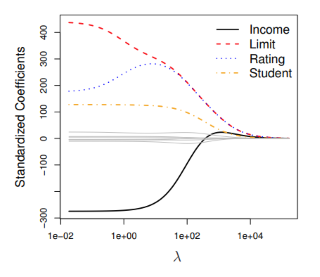

- **Regressão de Lasso**:

O modelo de regressão de Lasso surge na luz de uma clara disvantagem da de Ridge: esta utiliza todos as **features** $x_i$ no modelo. Isso se deve ao seu segundo termo, que reduz os coeficiente tendendo a zero, mas nunca chega a realmente zerá-los.

$$
RSS = \sum_{i=1}^n(y_i - \beta_0 - \sum_{j=1}^p \beta_jx_{ij})^2 + \lambda∑_{j=1}^p|\beta_j|
$$

No caso da regressão de Lasso, a inclusão da penalização - **penalidade L1** -, calculada como a soma dos valores absolutos dos coeficientes, possui o pontecial de zerar coeficientes de variáveis irrelevantes ao modelo. Desta forma, é possível realizar uma seleção das variáveis automaticamente.

A vantagem de Lasso é clara, na medida que a redução de variáveis irrelevantes, promove a simplicidade do modelo e uma melhor interpretação do problema.

Na imagem a seguir, vemos como os coeficientes de certas variáveis diminuem conforme λ aumenta. É essencial notar que os coeficientes chegam a assumir o valor de zero, diferentemente da regressão de Ridge.

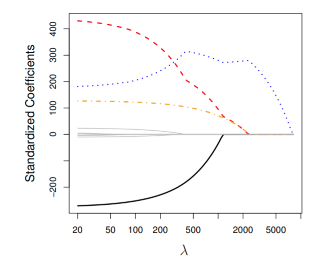

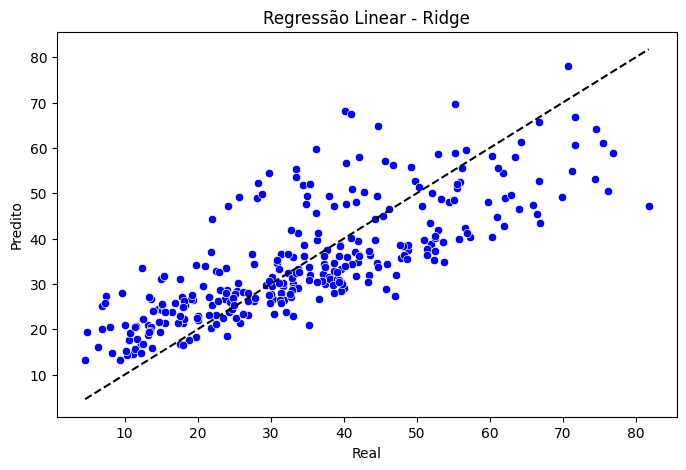

Desempenho do modelo (Ridge):
Erro Quadrático Médio (MSE): 109.750
Coeficiente de Determinação (R²): 0.594
--------------------------------------------------
Coeficientes da reta: intercecpto -> -59.61477835103553; coeficientes -> [ 0.12546435  0.11679064  0.09001435 -0.09058871  0.3964503   0.02810838
  0.03637476  0.11394191]


In [ ]:
# 5. Regressão Linear Ridge
from sklearn.linear_model import Ridge

lr_ridge = Ridge()
lr_ridge.fit(X_train, y_train)
y_pred_ridge = lr_ridge.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_ridge, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear - Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_ridge, X_test, y_test, y_pred_ridge)
print(f"Coeficientes da reta: intercecpto -> {lr_ridge.intercept_}; coeficientes -> {lr_ridge.coef_}")

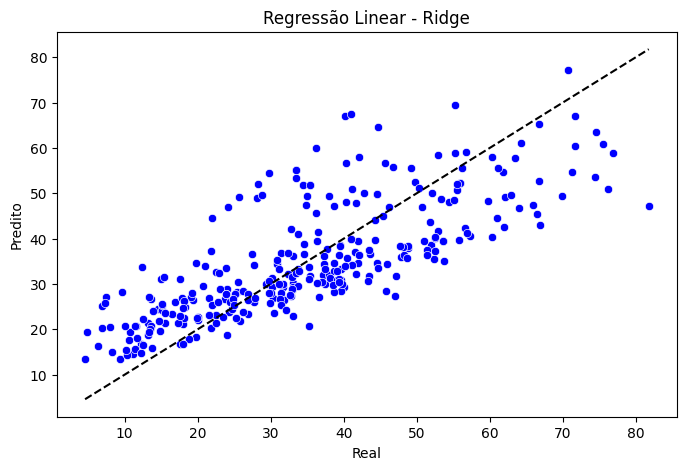

Desempenho do modelo (Ridge):
Erro Quadrático Médio (MSE): 109.238
Coeficiente de Determinação (R²): 0.596
--------------------------------------------------
Coeficientes da reta: intercecpto -> -50.27053528293231; coeficientes -> [ 0.12409949  0.11499988  0.08903832 -0.10671083  0.33326949  0.02459959
  0.03376438  0.11347018]


In [ ]:
# 6. Regressão Linear Lasso
from sklearn.linear_model import Lasso

lr_lasso = Lasso()
lr_lasso.fit(X_train, y_train)
y_pred_lasso = lr_lasso.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear - Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_ridge, X_test, y_test, y_pred_lasso)
print(f"Coeficientes da reta: intercecpto -> {lr_lasso.intercept_}; coeficientes -> {lr_lasso.coef_}")

# Apêndice

## Dimensões espaciais

Perceba que podemos ter pelo menos 1 feature $X_1$ para prever $Y$. Nesse caso, estamos trabalhando com um problema bidimensional (com duas dimensões: $Y$ e $X_1$), em que podemos representar no clássico plano cartesiano 2D em que estudamos na escola (com os eixos $Y$ e $X$). Para esse caso, queremos descobrir a reta que melhor representa a tendência dos dados.tridimensionais

Por outro lado, podemos ter 2 features ($X_1$ e $X_2$) para prever $Y$. Nesse caso, estamos trabalhando com um problema tridimensional (com três dimensões: $Y$, $X_1$ e $X_2$), em que podemos representar os espaços tridimensionais que estudamos na escola (com os eixos $Y$, $X$ e $Z$). Para esse caso, queremos descobrir o plano que melhor representa a tendência dos dados.


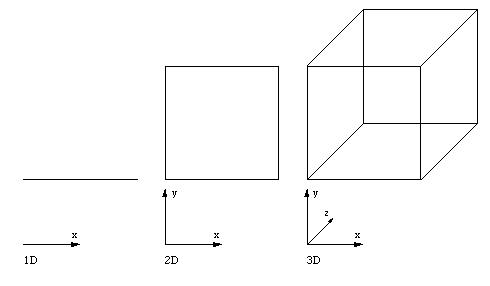



Porém, em problemas da vida real, é comum termos muito mais do que apenas 2 features. Para problemas com duas (2) dimensões ($Y$ e $X_1$), temos $2-1=1$ features; para problemas com três (3) dimensões ($Y$, $X_1$ e $X_2$), temos $3-1=2$ features. Portanto, para problemas com $n$ dimensões, teremos $n-1$ features. Perceba que para casos em que $n > 3$, não conseguimos criar visualizações gráficas visuais para visualizarmos o gráfico (caso duvide, tente desenhar um gráfico aí que possua não 3 dimensões, mas sim 4). Ainda sim, podemos trabalhar com esses espaços n-dimensionais. E para eles, vamos tentar descobrir o hiperplano que melhor representa a tendência dos dados. Pois, apesar de não conseguirmos visualizar esse espaço, conseguimos fazer contas com ele. É só pensar no seguinte: para você encontrar uma equação da reta, e para você fazer cálculos com a equação da reta, você não precisa ver o plano dimensional em si, você apenas precisa fazer cálculos, e isso não é diferente para espaços n-dimensionais.